# Problem Statement

Flight ticket prices fluctuate frequently depending on various factors such as airline, journey date, source, destination, duration, and number of stops.

The objective of this project is to build a Supervised Regression machine learning model that can accurately predict flight ticket prices and help customers plan their travel efficiently.

This can help airlines by predicting what prices they can maintain. 

# Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
data = pd.read_excel('Flight_Fare.xlsx')

In [3]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)


# Dataset Overview

In [4]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
data.shape

(10683, 11)

In [7]:
### Statistical Summary of Numerical Column
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


# Missing Value Analysis

In [8]:
data.isna().sum()   # df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
data[data["Route"].isna() | data["Total_Stops"].isna()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


# Handle Missing Values

In [10]:
data.dropna(inplace=True)

In [11]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

# Exploratory Data Analysis & Feature Engineering

## Target Variable Distribution (Price Distribution)

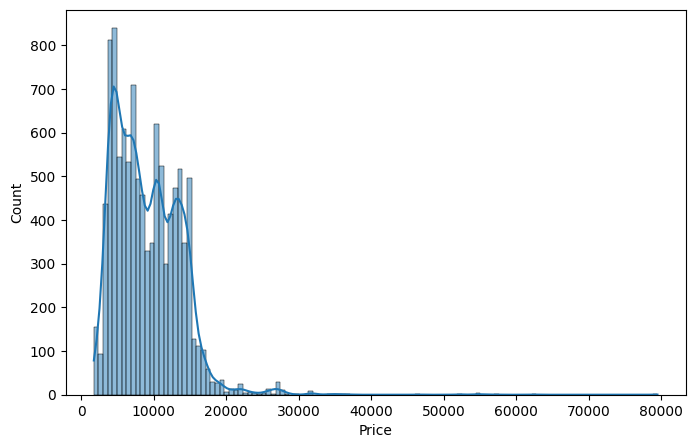

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data["Price"],kde=True)
plt.show()

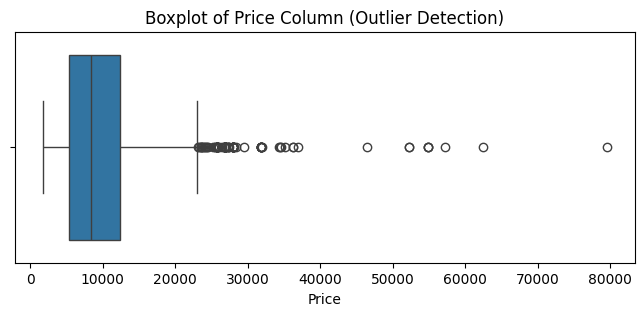

In [13]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=data["Price"])
plt.title("Boxplot of Price Column (Outlier Detection)")
plt.show()

## Airline Analysis

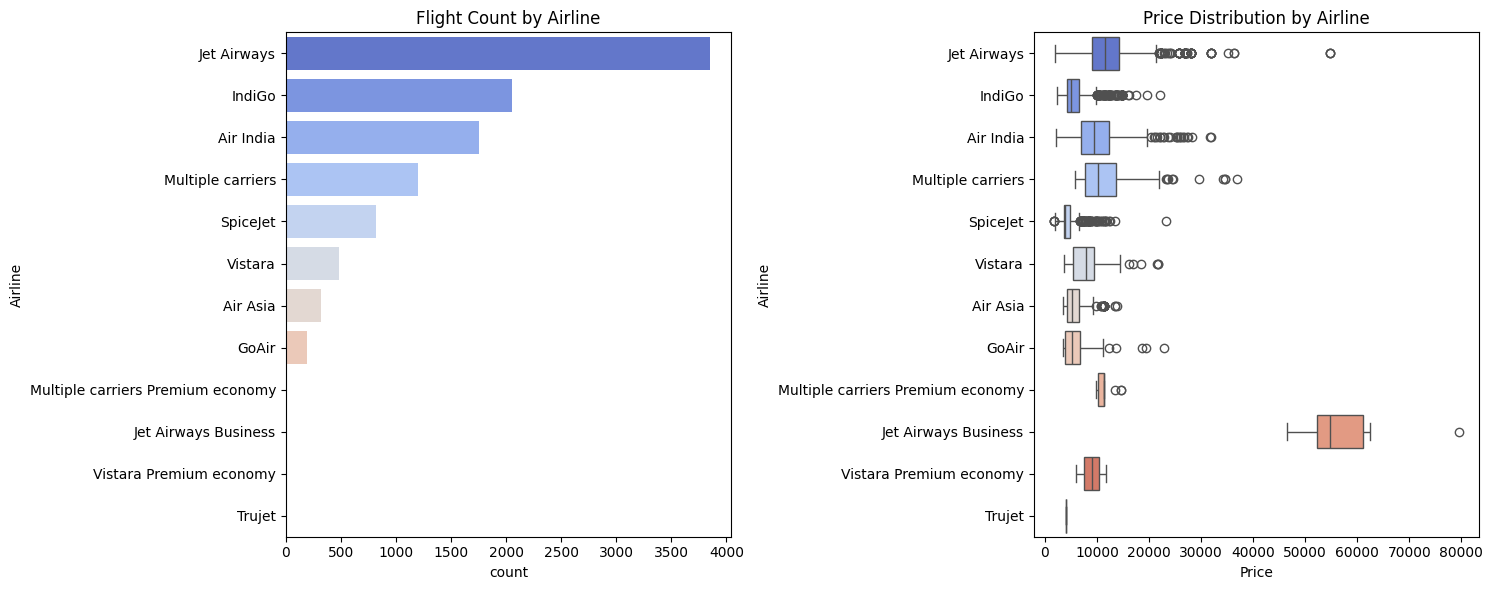

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
order = data["Airline"].value_counts().index

# Left plot: Horizontal count
sns.countplot(data=data, y="Airline", order=order, ax=axes[0],palette='coolwarm').set(
    title="Flight Count by Airline"
)

# Right plot: Horizontal boxplot
sns.boxplot(data=data, x="Price", y="Airline", order=order, ax=axes[1],palette='coolwarm').set(
    title="Price Distribution by Airline"
)

plt.tight_layout()
plt.show()

## Source & Destination Analysis

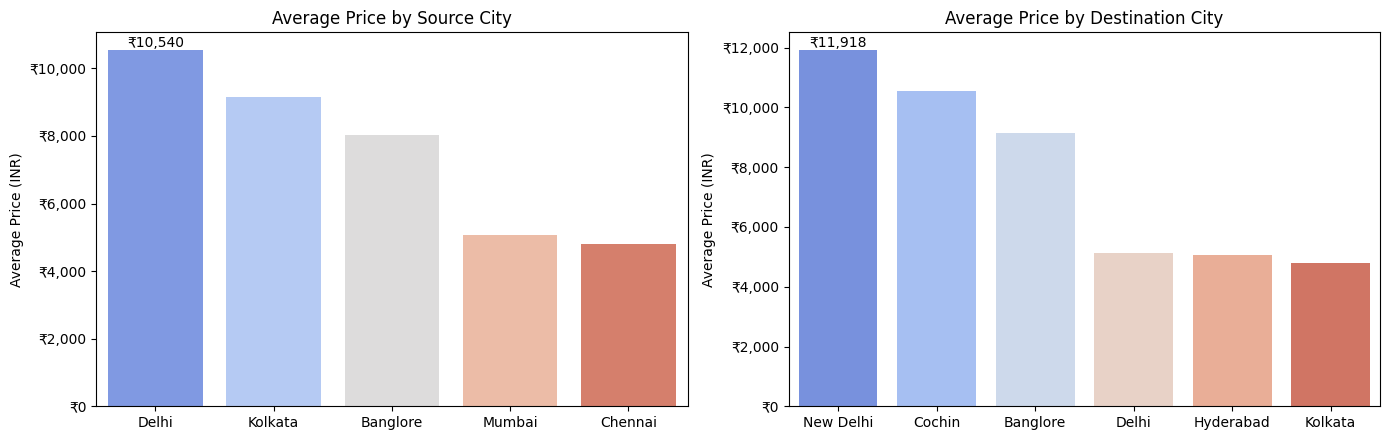

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, col in zip(axes, ["Source", "Destination"]):
    order = data.groupby(col)["Price"].mean().sort_values(ascending=False).index

    sns.barplot(data=data, x=col, y="Price", order=order, errorbar=None, ax=ax,palette='coolwarm')

    ax.set(title=f"Average Price by {col} City", ylabel="Average Price (INR)", xlabel="")
    
    # FIX: Explicitly create string labels to prevent version format errors
    container = ax.containers[0]
    labels = [f"₹{val:,.0f}" for val in container.datavalues]
    ax.bar_label(container, labels=labels)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"₹{x:,.0f}"))

plt.tight_layout()
plt.show()

## Stops Analysis

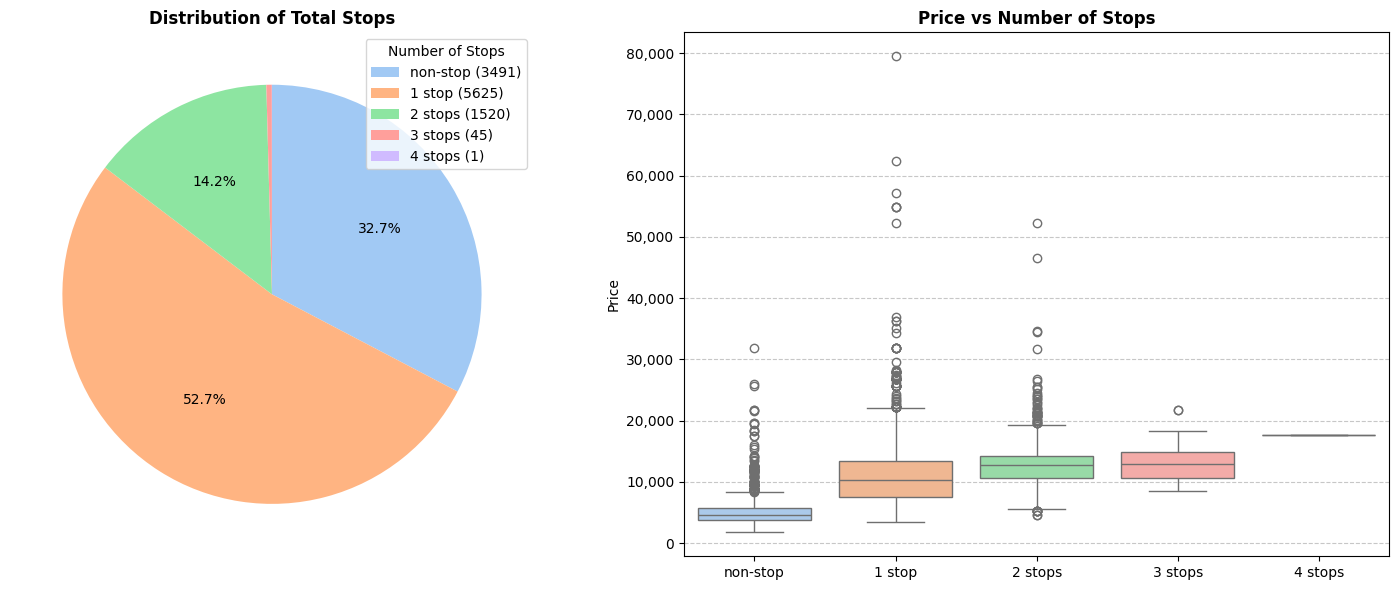

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Clean, logical ordering for flight stops
stops_order = ["non-stop", "1 stop", "2 stops", "3 stops", "4 stops"]
stops_counts = data["Total_Stops"].value_counts().reindex(stops_order).fillna(0)

# 1. Left Plot: Pie Chart with a Legend to entirely prevent label overlapping
wedges, texts, autotexts = axes[0].pie(
    stops_counts,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",  # Hide % text if slice is too tiny
    startangle=90,
    counterclock=False,
    colors=sns.color_palette("pastel")[: len(stops_order)],
)
axes[0].legend(
    wedges,
    [f"{label} ({int(val)})" for label, val in zip(stops_counts.index, stops_counts)],
    title="Number of Stops",
    loc="upper right",
    bbox_to_anchor=(1, 1),
)
axes[0].set_title("Distribution of Total Stops", fontweight="bold")

# 2. Right Plot: Box Plot for Price vs Number of Stops
sns.boxplot(
    data=data, x="Total_Stops", y="Price", order=stops_order, ax=axes[1], palette="pastel"
)
axes[1].set_title("Price vs Number of Stops", fontweight="bold")
axes[1].set(ylabel="Price", xlabel="")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## Duration
- Duration Parsing 

In [17]:
def convert_duration(duration):
    """Convert '2h 50m', '7h 25m' → total minutes."""
    if len(duration.split()) == 2:
        hours = int(duration.split()[0][:-1])
        minutes = int(duration.split()[1][:-1])
        return hours * 60 + minutes
    else:
        return int(duration[:-1]) * 60


In [18]:
# Filter rows that contain 'm' but do NOT contain 'h'
minutes_only_df = data[data["Duration"].str.contains("m") & ~data["Duration"].str.contains("h")]

# Display the total count and the matching rows
print(f"Total minutes-only rows found: {len(minutes_only_df)}")
minutes_only_df

Total minutes-only rows found: 1


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
6474,Air India,6/03/2019,Mumbai,Hyderabad,BOM → GOI → PNQ → HYD,16:50,16:55,5m,2 stops,No info,17327


In [19]:
# Remove the bad row from your data
data.drop(index=6474, inplace=True)

In [20]:
data["Duration"] = data["Duration"].apply(convert_duration)
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,170,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,445,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,1140,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,325,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,285,1 stop,No info,13302


## Departure and Arrival Time
- convertinng into datetime format

In [21]:
data['Dep_Time_in_hours'] = pd.to_datetime(data['Dep_Time'], format='%H:%M').dt.hour
data['Dep_Time_in_minutes']  = pd.to_datetime(data['Dep_Time'], format='%H:%M').dt.minute

# Arrival: some entries have next-day suffixes like "01:10 22 Mar" — strip them
data['Arrival_Time_Clean'] = data['Arrival_Time'].str.split(' ').str[0]
data['Arrival_Time_in_hours'] = pd.to_datetime(data['Arrival_Time_Clean'], format='%H:%M').dt.hour
data['Arrival_Time_in_minutes']  = pd.to_datetime(data['Arrival_Time_Clean'], format='%H:%M').dt.minute

In [22]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_Clean,Arrival_Time_in_hours,Arrival_Time_in_minutes
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,170,non-stop,No info,3897,22,20,01:10,1,10
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,445,2 stops,No info,7662,5,50,13:15,13,15


In [23]:
# Drop columns no longer needed
data.drop(["Dep_Time", "Arrival_Time","Arrival_Time_Clean"], axis=1, inplace=True)
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,22,20,1,10
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,5,50,13,15


## Date of Journey

In [24]:
data["Date_of_Journey"] = pd.to_datetime(data["Date_of_Journey"], dayfirst=True)
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,5,50,13,15


In [25]:
data['Date_of_Journey'].dt.year.unique()

array([2019], dtype=int32)

In [26]:
data["Day"] = data["Date_of_Journey"].dt.day
data["Month"] = data["Date_of_Journey"].dt.month
data["Weekday"] = data["Date_of_Journey"].dt.weekday
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes,Day,Month,Weekday
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,22,20,1,10,24,3,6
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,5,50,13,15,1,5,2


In [27]:
# Drop columns no longer needed
data.drop("Date_of_Journey", axis=1, inplace=True)
data.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes,Day,Month,Weekday
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,22,20,1,10,24,3,6
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,5,50,13,15,1,5,2


## Total Stops

In [28]:
data['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1519
3 stops       45
4 stops        1
Name: count, dtype: int64

In [29]:
# Total Stops → Ordinal Integer
data["Total_Stops"] = data["Total_Stops"].map(
    {"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}
)

In [30]:
data.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes,Day,Month,Weekday
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,0,No info,3897,22,20,1,10,24,3,6
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2,No info,7662,5,50,13,15,1,5,2


## Additional Info

In [31]:
# One-Hot Encoding for Categorical Features - Additional Info

Additional_Info = pd.get_dummies(data["Additional_Info"], drop_first=True)
data = pd.concat([data, Additional_Info], axis=1)
# Drop columns no longer needed
data.drop("Additional_Info", axis=1, inplace=True)
data.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes,Day,Month,Weekday,1 Short layover,2 Long layover,Business class,Change airports,In-flight meal not included,No Info,No check-in baggage included,No info,Red-eye flight
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,0,3897,22,20,1,10,24,3,6,False,False,False,False,False,False,False,True,False
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2,7662,5,50,13,15,1,5,2,False,False,False,False,False,False,False,True,False


In [34]:
data.select_dtypes(["object"]).columns

Index(['Airline', 'Source', 'Destination', 'Route'], dtype='object')

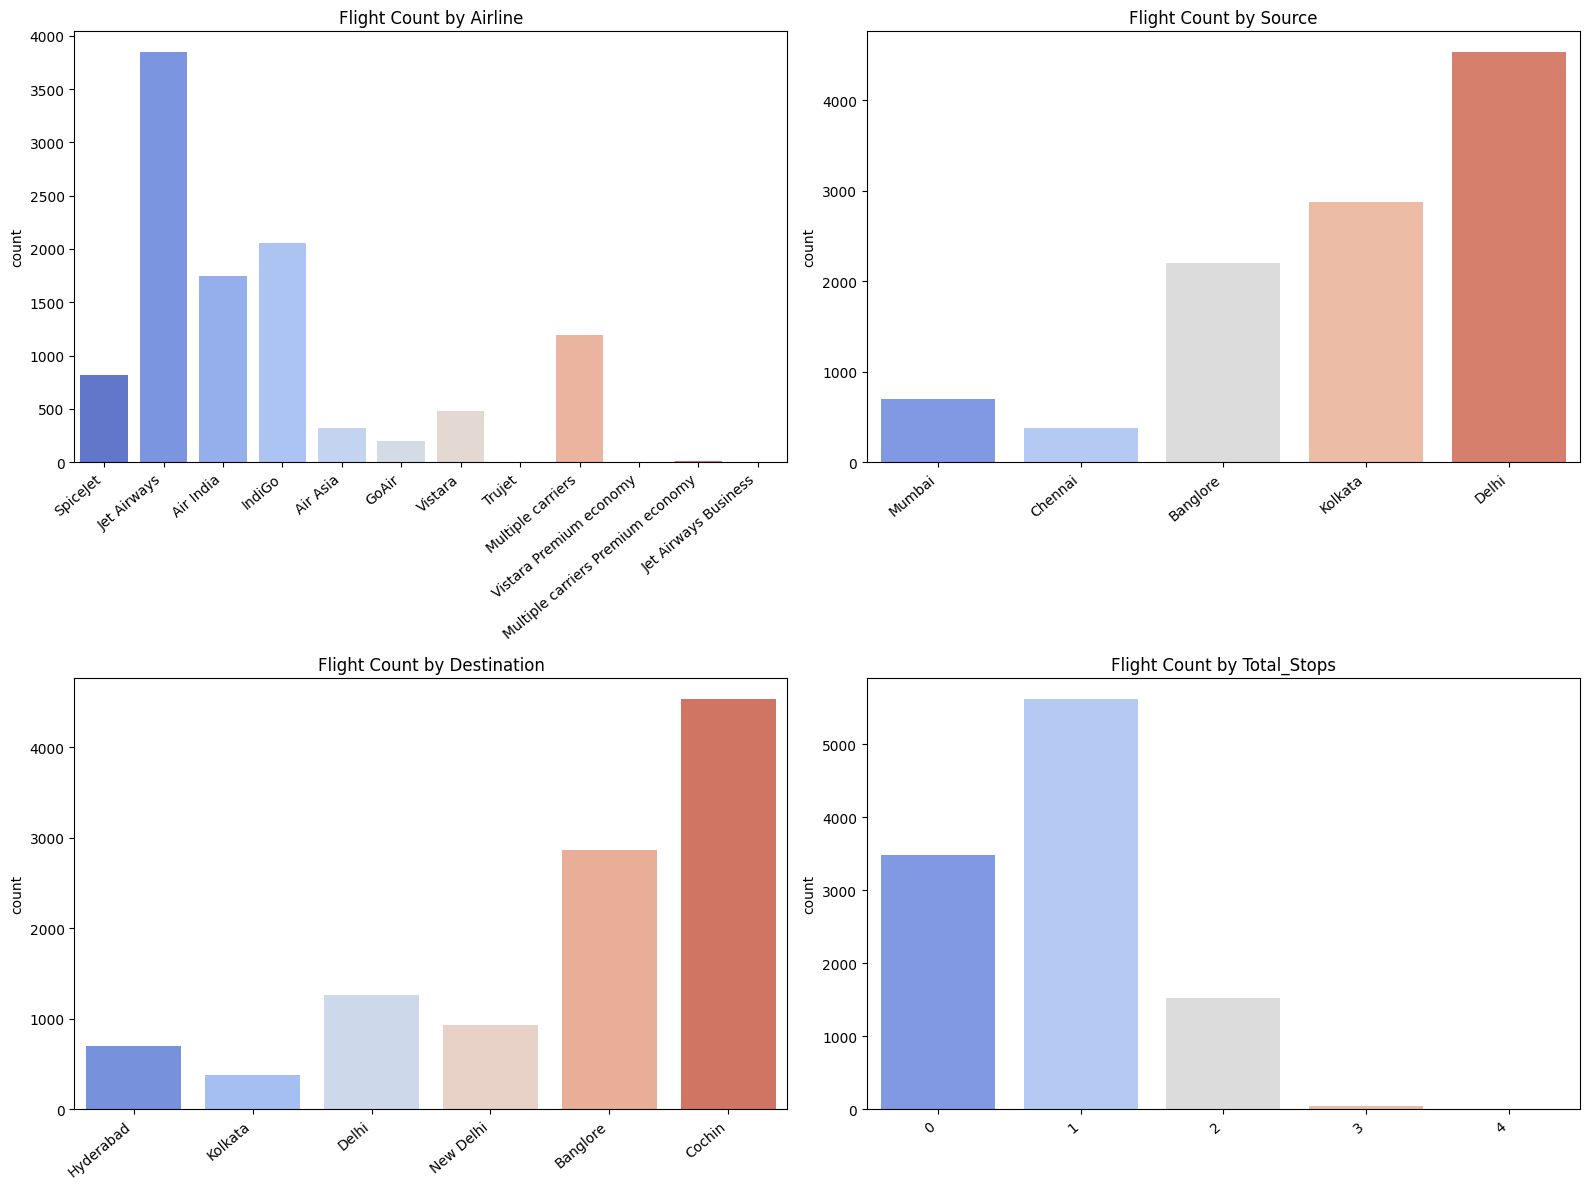

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
features = ["Airline", "Source", "Destination", "Total_Stops"]
axes_flat = axes.flatten() 
for ax, col in zip(axes_flat, features):
    sorted_data = data.sort_values("Price", ascending=True)
    sns.countplot(data=sorted_data, x=col, ax=ax,palette='coolwarm')
    ax.set_xticklabels( ax.get_xticklabels(), rotation=40, ha="right")
    ax.set(title=f"Flight Count by {col}", xlabel="", ylabel="count")

plt.tight_layout()
plt.show()

## Airline

In [38]:
data["Airline"].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1750
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

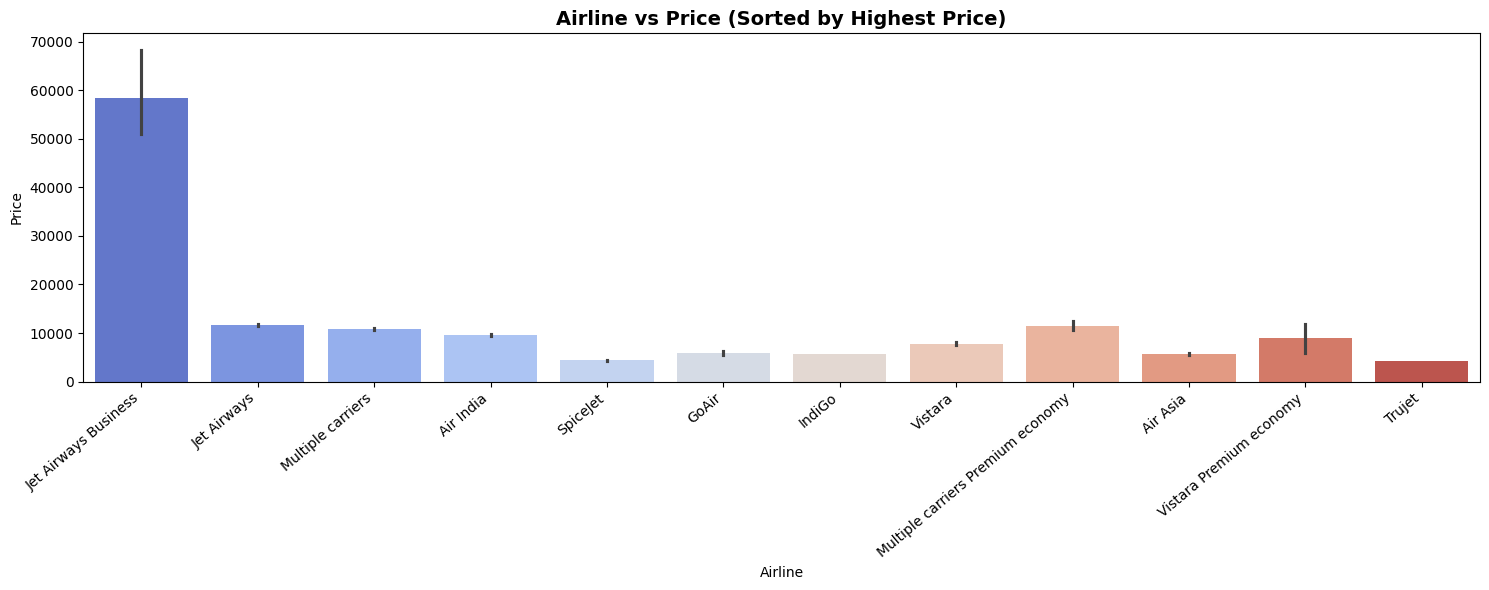

In [39]:
plt.figure(figsize=(15, 6))
ax = sns.barplot(x="Airline", y="Price", data=data.sort_values("Price", ascending=False),palette='coolwarm')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
plt.title("Airline vs Price (Sorted by Highest Price)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

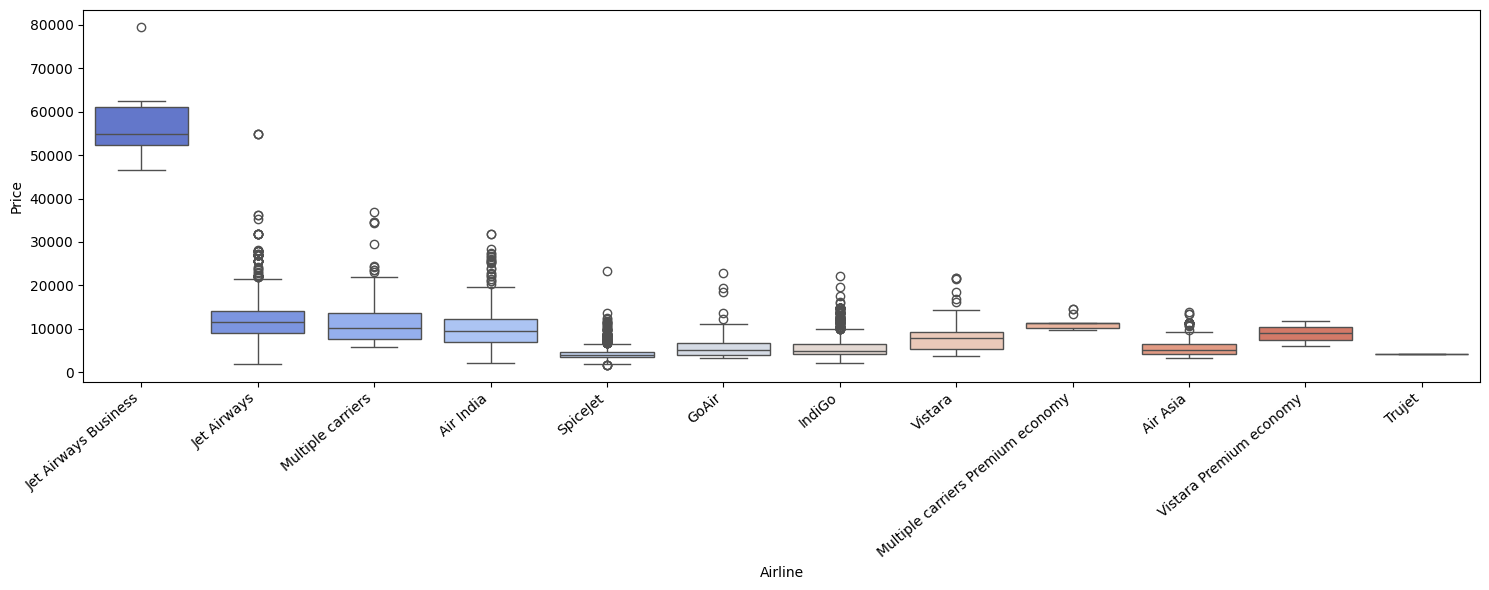

In [40]:
plt.figure(figsize=(15, 6))
ax = sns.boxplot(x="Airline", y="Price", data=data.sort_values("Price", ascending=False),palette='coolwarm')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
plt.tight_layout()
plt.show()

In [41]:
data.groupby("Airline").describe()["Price"].sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Airline,,,,,,,,
Jet Airways Business,6.0,58358.666667,11667.596748,46490.0,52243.0,54747.0,61122.50,79512.0
Jet Airways,3849.0,11643.923357,4258.940578,1840.0,9134.0,11467.0,14151.00,54826.0
Multiple carriers Premium economy,13.0,11418.846154,1717.153936,9845.0,10161.0,11269.0,11269.00,14629.0
Multiple carriers,1196.0,10902.678094,3721.234997,5797.0,7723.0,10197.0,13587.00,36983.0
Air India,1750.0,9608.019429,3898.485536,2050.0,6886.0,9443.0,12214.00,31945.0
Vistara Premium economy,3.0,8962.333333,2915.405518,5969.0,7547.0,9125.0,10459.00,11793.0
Vistara,479.0,7796.348643,2914.298578,3687.0,5403.0,7980.0,9345.00,21730.0
GoAir,194.0,5861.056701,2703.585767,3398.0,3898.0,5135.0,6811.25,22794.0
IndiGo,2053.0,5673.682903,2264.142168,2227.0,4226.0,5000.0,6494.00,22153.0


In [42]:
# One-Hot Encoding for Categorical Features
Airline = pd.get_dummies(data["Airline"], drop_first=True)
Airline.head()

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,False,False,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


In [43]:
data = pd.concat([data, Airline], axis=1)
data.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes,Day,Month,Weekday,1 Short layover,2 Long layover,Business class,Change airports,In-flight meal not included,No Info,No check-in baggage included,No info,Red-eye flight,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,0,3897,22,20,1,10,24,3,6,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2,7662,5,50,13,15,1,5,2,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False


In [44]:
# Drop columns no longer needed
data.drop("Airline", axis=1, inplace=True)
data.head(2)

,Source,Destination,Route,Duration,Total_Stops,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes,Day,Month,Weekday,1 Short layover,2 Long layover,Business class,Change airports,In-flight meal not included,No Info,No check-in baggage included,No info,Red-eye flight,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,Banglore,New Delhi,BLR → DEL,170,0,3897,22,20,1,10,24,3,6,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False
1,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2,7662,5,50,13,15,1,5,2,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False


## Source and Destination

In [45]:
list1 = ["Source", "Destination"]
for i in list1:
    print(data[i].value_counts(), "\n")

Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       696
Chennai      381
Name: count, dtype: int64 

Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     696
Kolkata       381
Name: count, dtype: int64 



In [46]:
data = pd.get_dummies(data=data, columns=list1, drop_first=True)
data.head(2)

,Route,Duration,Total_Stops,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes,Day,Month,Weekday,1 Short layover,2 Long layover,Business class,Change airports,In-flight meal not included,No Info,No check-in baggage included,No info,Red-eye flight,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,BLR → DEL,170,0,3897,22,20,1,10,24,3,6,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,CCU → IXR → BBI → BLR,445,2,7662,5,50,13,15,1,5,2,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


## Route

In [47]:
route = data[["Route"]]
route.head()

,Route
0,BLR → DEL
1,CCU → IXR → BBI → BLR
2,DEL → LKO → BOM → COK
3,CCU → NAG → BLR
4,BLR → NAG → DEL


In [48]:
data['Total_Stops'].value_counts()

Total_Stops
1    5625
0    3491
2    1519
3      45
4       1
Name: count, dtype: int64

In [49]:
route["Route_1"] = route["Route"].str.split("→").str[0]
route["Route_2"] = route["Route"].str.split("→").str[1]
route["Route_3"] = route["Route"].str.split("→").str[2]
route["Route_4"] = route["Route"].str.split("→").str[3]
route["Route_5"] = route["Route"].str.split("→").str[4]

route.head()

,Route,Route_1,Route_2,Route_3,Route_4,Route_5
0,BLR → DEL,BLR,DEL,NaN,NaN,NaN
1,CCU → IXR → BBI → BLR,CCU,IXR,BBI,BLR,NaN
2,DEL → LKO → BOM → COK,DEL,LKO,BOM,COK,NaN
3,CCU → NAG → BLR,CCU,NAG,BLR,NaN,NaN
4,BLR → NAG → DEL,BLR,NAG,DEL,NaN,NaN


In [50]:
route.fillna('None',inplace=True)
route.head()

,Route,Route_1,Route_2,Route_3,Route_4,Route_5
0,BLR → DEL,BLR,DEL,None,None,None
1,CCU → IXR → BBI → BLR,CCU,IXR,BBI,BLR,None
2,DEL → LKO → BOM → COK,DEL,LKO,BOM,COK,None
3,CCU → NAG → BLR,CCU,NAG,BLR,None,None
4,BLR → NAG → DEL,BLR,NAG,DEL,None,None


In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for i in range(1, 6):
    col = "Route_" + str(i)
    route[col] = le.fit_transform(route[col])

route.head()

,Route,Route_1,Route_2,Route_3,Route_4,Route_5
0,BLR → DEL,0,13,29,13,5
1,CCU → IXR → BBI → BLR,2,25,1,3,5
2,DEL → LKO → BOM → COK,3,32,4,5,5
3,CCU → NAG → BLR,2,34,3,13,5
4,BLR → NAG → DEL,0,34,8,13,5


In [52]:
route.drop("Route", axis=1, inplace=True)
route.head()

,Route_1,Route_2,Route_3,Route_4,Route_5
0,0,13,29,13,5
1,2,25,1,3,5
2,3,32,4,5,5
3,2,34,3,13,5
4,0,34,8,13,5


In [53]:
data = pd.concat([data, route], axis=1)
data.head(2)

,Route,Duration,Total_Stops,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes,Day,Month,Weekday,1 Short layover,2 Long layover,Business class,Change airports,In-flight meal not included,No Info,No check-in baggage included,No info,Red-eye flight,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Route_1,Route_2,Route_3,Route_4,Route_5
0,BLR → DEL,170,0,3897,22,20,1,10,24,3,6,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,0,13,29,13,5
1,CCU → IXR → BBI → BLR,445,2,7662,5,50,13,15,1,5,2,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,2,25,1,3,5


In [54]:
data.drop('Route',axis=1,inplace=True)
data.head()

,Duration,Total_Stops,Price,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes,Day,Month,Weekday,1 Short layover,2 Long layover,Business class,Change airports,In-flight meal not included,No Info,No check-in baggage included,No info,Red-eye flight,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Route_1,Route_2,Route_3,Route_4,Route_5
0,170,0,3897,22,20,1,10,24,3,6,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,0,13,29,13,5
1,445,2,7662,5,50,13,15,1,5,2,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,2,25,1,3,5
2,1140,2,13882,9,25,4,25,9,6,6,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,3,32,4,5,5
3,325,1,6218,18,5,23,30,12,5,6,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,2,34,3,13,5
4,285,1,13302,16,50,21,35,1,3,4,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,0,34,8,13,5


# Build the Machine Learning Model(s) & Evaluate them 

In [55]:
temp_col = data.columns.to_list()
print(temp_col, "\n")

new_col = temp_col[:2] + temp_col[3:]
new_col.append(temp_col[2])
print(new_col, "\n")

data = data.reindex(columns=new_col)
data.head()

['Duration', 'Total_Stops', 'Price', 'Dep_Time_in_hours', 'Dep_Time_in_minutes', 'Arrival_Time_in_hours', 'Arrival_Time_in_minutes', 'Day', 'Month', 'Weekday', '1 Short layover', '2 Long layover', 'Business class', 'Change airports', 'In-flight meal not included', 'No Info', 'No check-in baggage included', 'No info', 'Red-eye flight', 'Air India', 'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business', 'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet', 'Trujet', 'Vistara', 'Vistara Premium economy', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_New Delhi', 'Route_1', 'Route_2', 'Route_3', 'Route_4', 'Route_5'] 

['Duration', 'Total_Stops', 'Dep_Time_in_hours', 'Dep_Time_in_minutes', 'Arrival_Time_in_hours', 'Arrival_Time_in_minutes', 'Day', 'Month', 'Weekday', '1 Short layover', '2 Long layover', 'Business class', 'Change airports', 'In-fli

,Duration,Total_Stops,Dep_Time_in_hours,Dep_Time_in_minutes,Arrival_Time_in_hours,Arrival_Time_in_minutes,Day,Month,Weekday,1 Short layover,2 Long layover,Business class,Change airports,In-flight meal not included,No Info,No check-in baggage included,No info,Red-eye flight,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Route_1,Route_2,Route_3,Route_4,Route_5,Price
0,170,0,22,20,1,10,24,3,6,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,0,13,29,13,5,3897
1,445,2,5,50,13,15,1,5,2,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,2,25,1,3,5,7662
2,1140,2,9,25,4,25,9,6,6,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,3,32,4,5,5,13882
3,325,1,18,5,23,30,12,5,6,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,2,34,3,13,5,6218
4,285,1,16,50,21,35,1,3,4,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,0,34,8,13,5,13302


## Split Data for Training & Testing

In [56]:
from sklearn.model_selection import train_test_split as tts

# Separate features and target
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

x_train, x_test, y_train, y_test = tts(x, y, test_size=0.2, random_state=42,shuffle=True)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8544, 43)
(2137, 43)
(8544,)
(2137,)


## Feature Scaling

In [57]:
from sklearn.preprocessing import StandardScaler
# Normalizing the Data  - Standar Scaler
sc = StandardScaler()
sc.fit(x_train)
# Formula = z = (x-u)/s

x_train = sc.transform(x_train)
x_test = sc.transform(x_test)

## Train ML model

In [58]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train, predict and return metrics dict."""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    
    r2   = r2_score(y_te, pred)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
    
    # 5-fold CV R²
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')
    cv_mean = cv_scores.mean()
    
    print(f"  {'─'*50}")
    print(f"  {name}")
    print(f"  {'─'*50}")
    print(f"    R²         : {r2:.4f}")
    print(f"    MAE        : ₹{mae:,.2f}")
    print(f"    RMSE       : ₹{rmse:,.2f}")
    print(f"    MAPE       : {mape:.2f}%")
    print(f"    CV R² (5k) : {cv_mean:.4f} ± {cv_scores.std():.4f}")
    print()
    
    return {
        'Model': name, 'R²': round(r2,4), 'MAE': round(mae,2),
        'RMSE': round(rmse,2), 'MAPE (%)': round(mape,2),
        'CV R²': round(cv_mean,4), 'model_obj': model, 'predictions': pred
    }

results = []
print("✅ Evaluation helper ready.")

✅ Evaluation helper ready.


### Linear Models

In [59]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV
print("Training Linear Models...")
print()

res = evaluate_model('Linear Regression', LinearRegression(), x_train, y_train, x_test, y_test)
results.append(res)

res = evaluate_model('Ridge Regression (α=10)', Ridge(alpha=10), x_train, y_train, x_test, y_test)
results.append(res)

res = evaluate_model('Lasso Regression (α=10)', Lasso(alpha=10), x_train, y_train, x_test, y_test)
results.append(res)

Training Linear Models...

  ──────────────────────────────────────────────────
  Linear Regression
  ──────────────────────────────────────────────────
    R²         : 0.7157
    MAE        : ₹1,693.45
    RMSE       : ₹2,449.99
    MAPE       : 20.41%
    CV R² (5k) : 0.6959 ± 0.0329

  ──────────────────────────────────────────────────
  Ridge Regression (α=10)
  ──────────────────────────────────────────────────
    R²         : 0.7152
    MAE        : ₹1,695.16
    RMSE       : ₹2,452.25
    MAPE       : 20.41%
    CV R² (5k) : 0.6955 ± 0.0331

  ──────────────────────────────────────────────────
  Lasso Regression (α=10)
  ──────────────────────────────────────────────────
    R²         : 0.7105
    MAE        : ₹1,701.68
    RMSE       : ₹2,472.34
    MAPE       : 20.36%
    CV R² (5k) : 0.6918 ± 0.0337



### Tree-Based Models

In [60]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
print("Training Tree-Based Models...")
print()

res = evaluate_model('Decision Tree', 
                     DecisionTreeRegressor(max_depth=10, random_state=42),
                     x_train, y_train, x_test, y_test)
results.append(res)

res = evaluate_model('Extra Trees Regressor', 
                     ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                     x_train, y_train, x_test, y_test)
results.append(res)

Training Tree-Based Models...

  ──────────────────────────────────────────────────
  Decision Tree
  ──────────────────────────────────────────────────
    R²         : 0.8561
    MAE        : ₹926.38
    RMSE       : ₹1,742.90
    MAPE       : 10.66%
    CV R² (5k) : 0.8054 ± 0.0392

  ──────────────────────────────────────────────────
  Extra Trees Regressor
  ──────────────────────────────────────────────────
    R²         : 0.9249
    MAE        : ₹555.34
    RMSE       : ₹1,259.48
    MAPE       : 6.48%
    CV R² (5k) : 0.8961 ± 0.0240



### Ensemble Models

In [61]:
print("Training Ensemble Models ..")
print()

res = evaluate_model('Random Forest (n=150)', 
                     RandomForestRegressor(n_estimators=150, max_depth=None, 
                                           min_samples_leaf=2, random_state=42, n_jobs=-1),
                     x_train, y_train, x_test, y_test)
results.append(res)

res = evaluate_model('Gradient Boosting (n=200)', 
                     GradientBoostingRegressor(n_estimators=200, learning_rate=0.08,
                                               max_depth=5, subsample=0.8, random_state=42),
                     x_train, y_train, x_test, y_test)
results.append(res)

Training Ensemble Models ..

  ──────────────────────────────────────────────────
  Random Forest (n=150)
  ──────────────────────────────────────────────────
    R²         : 0.8938
    MAE        : ₹606.27
    RMSE       : ₹1,497.37
    MAPE       : 6.91%
    CV R² (5k) : 0.8815 ± 0.0289

  ──────────────────────────────────────────────────
  Gradient Boosting (n=200)
  ──────────────────────────────────────────────────
    R²         : 0.9126
    MAE        : ₹826.74
    RMSE       : ₹1,358.43
    MAPE       : 9.70%
    CV R² (5k) : 0.8812 ± 0.0249



### XGBoost — Advanced Boosting

In [62]:
from xgboost import XGBRegressor
print("Training XGBoost...")
print()

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

res = evaluate_model('XGBoost Regressor', xgb_model, x_train, y_train, x_test, y_test)
results.append(res)

Training XGBoost...

  ──────────────────────────────────────────────────
  XGBoost Regressor
  ──────────────────────────────────────────────────
    R²         : 0.9251
    MAE        : ₹698.71
    RMSE       : ₹1,257.27
    MAPE       : 8.08%
    CV R² (5k) : 0.8951 ± 0.0322



## Model Comparison Report

In [64]:
# ── Summary Table ────────────────────────────────────────────────
summary_cols = ['Model', 'R²', 'MAE', 'RMSE', 'MAPE (%)', 'CV R²']
results_df = pd.DataFrame(results)[summary_cols].sort_values('R²', ascending=False)

print("=" * 85)
print("                        MODEL COMPARISON REPORT")
print("=" * 85)
print(results_df.to_string(index=False))
print("=" * 85)
print("\n✅ Best Model by R²       :", results_df.iloc[0]['Model'])
print("✅ Best Model by MAE       :", results_df.loc[results_df['MAE'].idxmin(), 'Model'])
print("✅ Best Model by CV R²     :", results_df.loc[results_df['CV R²'].idxmax(), 'Model'])

                        MODEL COMPARISON REPORT
                    Model     R²     MAE    RMSE  MAPE (%)  CV R²
        XGBoost Regressor 0.9251  698.71 1257.27      8.08 0.8951
    Extra Trees Regressor 0.9249  555.34 1259.48      6.48 0.8961
Gradient Boosting (n=200) 0.9126  826.74 1358.43      9.70 0.8812
    Random Forest (n=150) 0.8938  606.27 1497.37      6.91 0.8815
            Decision Tree 0.8561  926.38 1742.90     10.66 0.8054
        Linear Regression 0.7157 1693.45 2449.99     20.41 0.6959
  Ridge Regression (α=10) 0.7152 1695.16 2452.25     20.41 0.6955
  Lasso Regression (α=10) 0.7105 1701.68 2472.34     20.36 0.6918

✅ Best Model by R²       : XGBoost Regressor
✅ Best Model by MAE       : Extra Trees Regressor
✅ Best Model by CV R²     : Extra Trees Regressor


## Hyperparameter Tuning (Extra Trees Regressor)

In [67]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
# RandomizedSearchCV 
param_dist = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'max_depth'        : [None, 20, 30, 40],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.4, 0.6, 0.8],
    'bootstrap'        : [True, False],
}

random_search = RandomizedSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter      = 40,
    cv          = 5,
    scoring     = 'r2',
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1,
    refit       = True
)

random_search.fit(x_train, y_train)
print(f"Best CV R² : {random_search.best_score_:.4f}")
print("\nBest Params:")
for k, v in random_search.best_params_.items():
    print(f"  {k:<22}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV R² : 0.9017

Best Params:
  n_estimators          : 500
  min_samples_split     : 6
  min_samples_leaf      : 1
  max_features          : 0.8
  max_depth             : 30
  bootstrap             : False


In [68]:
# GridSearchCV (fine-tune around best params) ──────────
bp = random_search.best_params_
n  = bp['n_estimators']

grid = {
    'n_estimators'     : sorted({max(50, n-100), n, n+100}),
    'max_depth'        : [bp['max_depth']],
    'min_samples_split': sorted({max(2, bp['min_samples_split']-2),
                                  bp['min_samples_split'],
                                  bp['min_samples_split']+2}),
    'min_samples_leaf' : sorted({max(1, bp['min_samples_leaf']-1),
                                  bp['min_samples_leaf'],
                                  bp['min_samples_leaf']+1}),
    'max_features'     : [bp['max_features']],
    'bootstrap'        : [bp['bootstrap']],
}

grid_search = GridSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    param_grid = grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)

grid_search.fit(x_train, y_train)
print(f"Best CV R² : {grid_search.best_score_:.4f}")
print("\nFinal Best Params:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<22}: {v}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best CV R² : 0.9025

Final Best Params:
  bootstrap             : False
  max_depth             : 30
  max_features          : 0.8
  min_samples_leaf      : 1
  min_samples_split     : 4
  n_estimators          : 600


## Evaluate Tuned Extra Trees Regressor

In [74]:
tuned_et   = grid_search.best_estimator_
tuned_pred = tuned_et.predict(x_test)

r2   = r2_score(y_test, tuned_pred)
mae  = mean_absolute_error(y_test, tuned_pred)
rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
mape = np.mean(np.abs((y_test - tuned_pred) / y_test)) * 100
cv   = cross_val_score(tuned_et, x_train, y_train, cv=5, scoring='r2')

# ── Baseline for comparison ───────────────────────────────────────
et_base   = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
et_base.fit(x_train, y_train)
base_pred = et_base.predict(x_test)
base_r2   = r2_score(y_test, base_pred)
base_mae  = mean_absolute_error(y_test, base_pred)
base_rmse = np.sqrt(mean_squared_error(y_test, base_pred))

print("=" * 58)
print("      TUNED EXTRA TREES — FINAL EVALUATION")
print("=" * 58)
print(f"  Metric        Baseline       Tuned")
print(f"  {'─'*44}")
print(f"  R²          : {base_r2:.4f}    →   {r2:.4f}  {'✅ improved' if r2 > base_r2 else ''}")
print(f"  MAE         : ₹{base_mae:,.2f}  →  ₹{mae:,.2f}  {'✅ improved' if mae < base_mae else ''}")
print(f"  RMSE        : ₹{base_rmse:,.2f}  →  ₹{rmse:,.2f}  {'✅ improved' if rmse < base_rmse else ''}")
print(f"  MAPE        :             {mape:.2f}%")
print(f"  CV R² (5k)  :  {cv.mean():.4f} ± {cv.std():.4f}")
print("=" * 58)
imp = (base_mae - mae) / base_mae * 100
print(f"\n📈 MAE improved by {imp:.1f}% after tuning")
print(f"\nBest Hyperparameters used:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<22}: {v}")


      TUNED EXTRA TREES — FINAL EVALUATION
  Metric        Baseline       Tuned
  ────────────────────────────────────────────
  R²          : 0.9249    →   0.9321  ✅ improved
  MAE         : ₹555.34  →  ₹557.35  
  RMSE        : ₹1,259.48  →  ₹1,197.66  ✅ improved
  MAPE        :             6.48%
  CV R² (5k)  :  0.9025 ± 0.0296

📈 MAE improved by -0.4% after tuning

Best Hyperparameters used:
  bootstrap             : False
  max_depth             : 30
  max_features          : 0.8
  min_samples_leaf      : 1
  min_samples_split     : 4
  n_estimators          : 600


##  Save Best Model - Extra Trees Regressor (Hyperparameter-Tuned)

In [76]:
import pickle

with open("extra_trees_flight_fare_tuned.pkl", "wb") as file:
    pickle.dump(tuned_et, file)
print("Model saved as → extra_trees_flight_fare_tuned.pkl")

Model saved as → extra_trees_flight_fare_tuned.pkl


In [77]:
# Load later:
import pickle
with open("extra_trees_flight_fare_tuned.pkl", "rb") as file:
    loaded_model = pickle.load(file)

## Challenges Faced During the Project

- Inconsistent Date Formats
Date_of_Journey had mixed formats like 1/05/2019 and 24/03/2019. Fixed using pd.to_datetime(dayfirst=True).

- Messy Arrival Time
Some entries had next-day text like "01:10 22 Mar". Stripped the suffix using .str.split(' ').str[0] before parsing.

- Duration as Free Text
"2h 50m", "45m", "7h" couldn't be used directly. Wrote a custom parser to convert everything into total minutes.

- Stops Column was Ordinal Text
"non-stop", "1 stop", "2 stops" are ordered categories. Used manual mapping (0, 1, 2…) instead of one-hot encoding to preserve the natural order.

- Additional Info — Dominated by "No info"
Over 78% of values were "No info". Retained the column because rare values like "Business class" carried strong price signal.

- Right-Skewed Price Distribution
Price was heavily skewed with a long tail above ₹50,000. Chose tree-based models which handle skew natively — no log transformation needed.

- Route Column Was Raw Text
Routes like "BLR → DEL → BOM" had variable length. Split into 5 positional columns (Route_1 to Route_5) and label-encoded each.
